# MediVision AI — Predictive Health Analytics

**Objective:** Build a reusable machine learning pipeline to predict multiple health conditions (Diabetes, Hypertension, Heart Disease, Asthma, Stroke, Arthritis) using the CDC NHANES 2017–March 2020 pre-pandemic data.

In [144]:
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import classification_report, roc_auc_score

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")

# Setup directories
DATA_DIR = Path("../data/raw")
DATA_DIR.mkdir(parents=True, exist_ok=True)
print(f"Data directory set to: {DATA_DIR.resolve()}")

Data directory set to: D:\depi_graduation_project\MediVision-AI\data\raw


## 1. Data Acquisition
Download the raw NHANES XPT files from the CDC website if they do not already exist.

In [145]:
import requests
from tqdm.auto import tqdm

FILES = {
    "P_DEMO.xpt": "https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/P_DEMO.xpt",
    "P_BMX.xpt": "https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/P_BMX.xpt",
    "P_BPXO.xpt": "https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/P_BPXO.xpt",
    "P_BPQ.xpt": "https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/P_BPQ.xpt",
    "P_PAQ.xpt": "https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/P_PAQ.xpt",
    "P_SMQ.xpt": "https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/P_SMQ.xpt",
    "P_HSQ.xpt": "https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/P_HSQ.xpt",
    "P_DIQ.xpt": "https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/P_DIQ.xpt",
    "P_MCQ.xpt": "https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/P_MCQ.xpt",
    "P_GHB.xpt": "https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/P_GHB.xpt",
    "P_GLU.xpt": "https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/P_GLU.xpt",
    "P_HDL.xpt": "https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/P_HDL.xpt",
    "P_TCHOL.xpt": "https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/P_TCHOL.xpt",
    "P_TRIGLY.xpt": "https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/P_TRIGLY.xpt",
}

missing_files = [f for f in FILES.keys() if not (DATA_DIR / f).exists()]

if not missing_files:
    print("All NHANES data files are already downloaded.")
else:
    print(f"Downloading {len(missing_files)} missing files...")
    for filename in missing_files:
        r = requests.get(FILES[filename], stream=True, timeout=60)
        r.raise_for_status()
        with open(DATA_DIR / filename, "wb") as f:
            for chunk in r.iter_content(chunk_size=1024 * 1024):
                if chunk: f.write(chunk)
    print("Download complete.")

All NHANES data files are already downloaded.


## 2. Data Integration & Cleaning
Merge all files on respondent ID (`SEQN`), rename cryptic variables, filter to adults, and generate our 6 disease target columns.

In [146]:
# Load and Merge
file_list = list(FILES.keys())
df = pd.read_sas(DATA_DIR / file_list[0], format='xport')
for f in file_list[1:]:
    temp = pd.read_sas(DATA_DIR / f, format='xport')
    df = df.merge(temp, on='SEQN', how='left')

# Drop survey admin columns
admin_cols = ["SIALANG", "SIAPROXY", "SIAINTRP", "FIALANG", "FIAPROXY", "FIAINTRP", 
              "MIALANG", "MIAPROXY", "MIAINTRP", "AIALANGA", "BMDSTATS", "SMAQUEX2", "SDDSRVYR", "RIDSTATR", "RIDEXMON"]
df = df.drop(columns=[c for c in admin_cols if c in df.columns])

# Rename key features
rename_dict = {
    "RIAGENDR": "gender", "RIDAGEYR": "age", "RIDRETH3": "ethnicity",
    "DMDEDUC2": "education", "DMDMARTZ": "marital_status",
    "INDFMPIR": "income_poverty_ratio", "BMXWT": "weight_kg",
    "BMXHT": "height_cm", "BMXBMI": "bmi", "BMXWAIST": "waist_cm",
    "BMXHIP": "hip_cm", "LBXGH": "hba1c", "LBXGLU": "fasting_glucose",
    "LBDHDD": "hdl", "LBXTC": "total_cholesterol", "LBXTR": "triglycerides",
    "LBDLDL": "ldl", "SMQ020": "ever_smoked", "PAD680": "sedentary_minutes"
}
df = df.rename(columns=rename_dict)

# Filter to adults (>= 18 years)
if 'age' in df.columns:
    df = df[df['age'] >= 18].copy()

# Generate Disease Targets (1 = Positive, 0 = Negative/Borderline)
if 'DIQ010' in df.columns:
    df['target_diabetes'] = np.where(df['DIQ010'] == 1, 1, np.where(df['DIQ010'].isin([2, 3]), 0, np.nan))
if 'BPQ020' in df.columns:
    df['target_hypertension'] = np.where(df['BPQ020'] == 1, 1, np.where(df['BPQ020'] == 2, 0, np.nan))
if all(c in df.columns for c in ['MCQ160C', 'MCQ160D', 'MCQ160E']):
    df['target_heart_disease'] = np.where((df['MCQ160C'] == 1) | (df['MCQ160D'] == 1) | (df['MCQ160E'] == 1), 1, 
                                          np.where((df['MCQ160C'] == 2) & (df['MCQ160D'] == 2) & (df['MCQ160E'] == 2), 0, np.nan))
if 'MCQ010' in df.columns:
    df['target_asthma'] = np.where(df['MCQ010'] == 1, 1, np.where(df['MCQ010'] == 2, 0, np.nan))
if 'MCQ160F' in df.columns:
    df['target_stroke'] = np.where(df['MCQ160F'] == 1, 1, np.where(df['MCQ160F'] == 2, 0, np.nan))
if 'MCQ160A' in df.columns:
    df['target_arthritis'] = np.where(df['MCQ160A'] == 1, 1, np.where(df['MCQ160A'] == 2, 0, np.nan))

disease_targets = [c for c in df.columns if c.startswith('target_')]

# Define the clinical features we will use for modeling
useful_features = [
    'age', 'gender', 'ethnicity', 'bmi', 'waist_cm', 'weight_kg', 'height_cm',
    'hba1c', 'fasting_glucose', 'total_cholesterol', 'hdl', 'triglycerides', 'ldl',
    'ever_smoked', 'sedentary_minutes', 'education', 'income_poverty_ratio'
]
selected_features = [f for f in useful_features if f in df.columns]

print(f"Data Cleaning Complete. Final shape: {df.shape}")
print(f"Identified {len(disease_targets)} disease targets.")

Data Cleaning Complete. Final shape: (9693, 200)
Identified 6 disease targets.


## 3. Exploratory Data Analysis
Visualize the target imbalances and key physiological correlations.

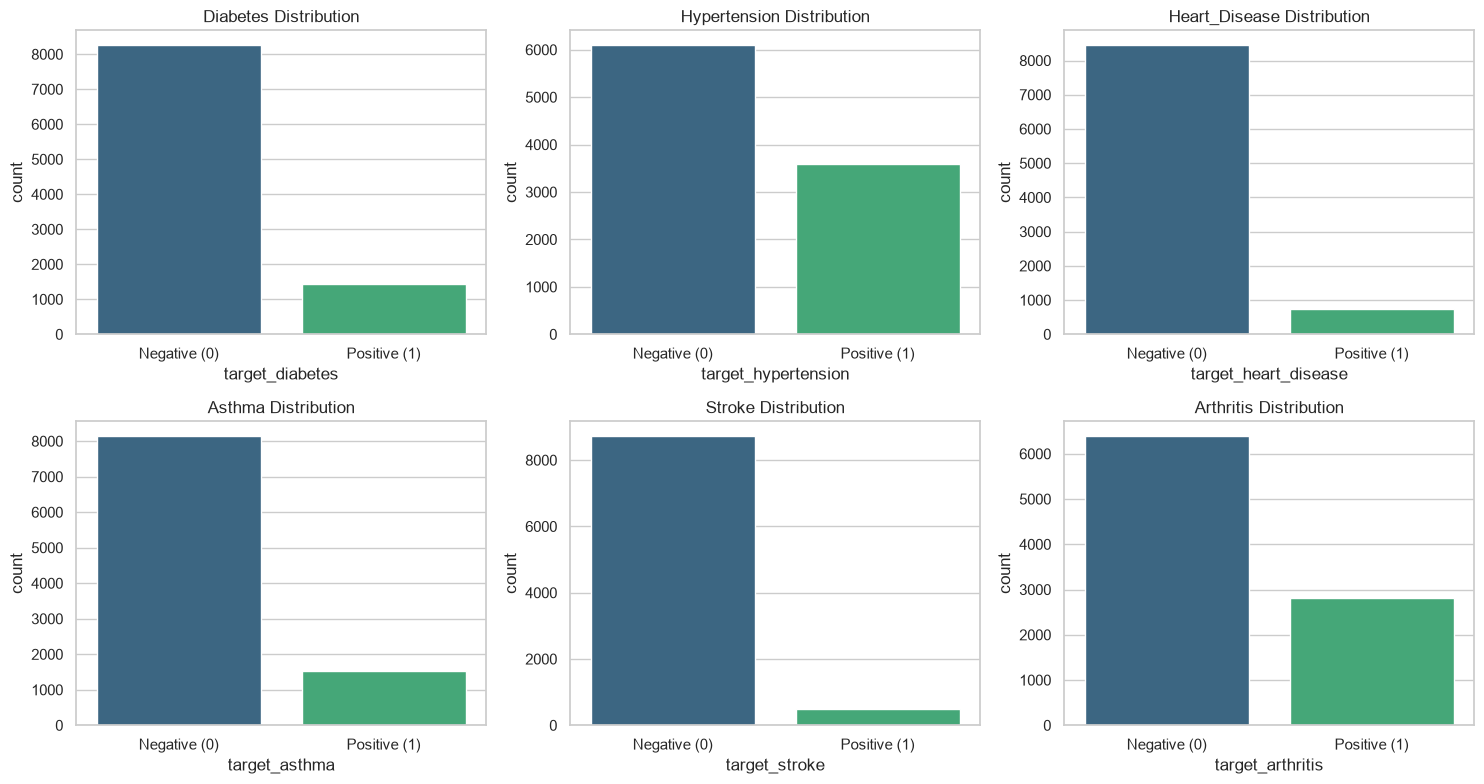

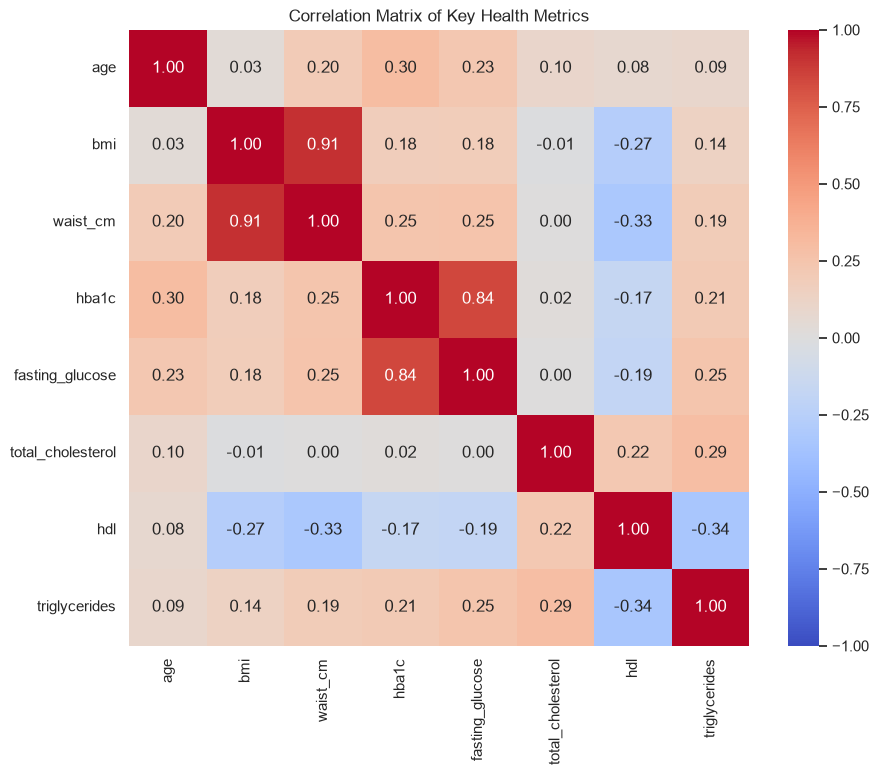

In [147]:
# 1. Target Distributions
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, target in enumerate(disease_targets):
    sns.countplot(data=df, x=target, ax=axes[i], palette="viridis")
    axes[i].set_title(f"{target.replace('target_', '').title()} Distribution")
    axes[i].set_xticklabels(['Negative (0)', 'Positive (1)'])

plt.tight_layout()
plt.show()

# 2. Correlation Matrix of Key Health Metrics
num_cols = ['age', 'bmi', 'waist_cm', 'hba1c', 'fasting_glucose', 'total_cholesterol', 'hdl', 'triglycerides']
existing_num = [c for c in num_cols if c in df.columns]

plt.figure(figsize=(10, 8))
corr_matrix = df[existing_num].corr()
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)
plt.title("Correlation Matrix of Key Health Metrics")
plt.show()

## 4. Multi-Disease Predictive Modeling
We train a separate `HistGradientBoostingClassifier` for each disease. This algorithm handles NaNs directly, making it highly efficient. We apply strict regularization to avoid overfitting.

In [148]:
trained_models = {}

for disease in disease_targets:
    disease_name = disease.replace('target_', '').replace('_', ' ').upper()
    print(f"\n{'='*50}\nTraining Model: {disease_name}\n{'='*50}")
    
    # Drop rows missing this specific target
    df_disease = df.dropna(subset=[disease]).copy()
    
    X = df_disease[selected_features]
    y = df_disease[disease]
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    
    # Model instantiation with strict anti-overfitting constraints
    model = HistGradientBoostingClassifier(
        max_depth=5,              # Shallow trees prevent memorization
        l2_regularization=1.0,    # Penalize complex weights
        learning_rate=0.05,       
        max_iter=150,
        random_state=42, 
        class_weight='balanced'   # Balances underrepresented positive cases
    )
    
    model.fit(X_train, y_train)
    trained_models[disease] = model
    
    # Generalization Check
    train_auc = roc_auc_score(y_train, model.predict_proba(X_train)[:, 1])
    test_auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
    delta = train_auc - test_auc
    
    print(f"Test ROC-AUC:  {test_auc:.4f} (Train: {train_auc:.4f})")
    print(f"Overfit Delta: {delta:.4f} " + ("✅ (Good Generalization)" if delta < 0.1 else "⚠️ (Warning: Overfitting)"))


Training Model: DIABETES
Test ROC-AUC:  0.9338 (Train: 0.9760)
Overfit Delta: 0.0422 ✅ (Good Generalization)

Training Model: HYPERTENSION
Test ROC-AUC:  0.8110 (Train: 0.8848)
Overfit Delta: 0.0738 ✅ (Good Generalization)

Training Model: HEART DISEASE
Test ROC-AUC:  0.7995 (Train: 0.9586)
Overfit Delta: 0.1591 ⚠️ (Warning: Overfitting)

Training Model: ASTHMA
Test ROC-AUC:  0.5685 (Train: 0.8703)
Overfit Delta: 0.3018 ⚠️ (Warning: Overfitting)

Training Model: STROKE
Test ROC-AUC:  0.7757 (Train: 0.9766)
Overfit Delta: 0.2009 ⚠️ (Warning: Overfitting)

Training Model: ARTHRITIS
Test ROC-AUC:  0.7788 (Train: 0.8841)
Overfit Delta: 0.1053 ⚠️ (Warning: Overfitting)


## 5. Comprehensive Disease Risk Report
Generates a unified health risk profile for a patient by querying all 6 models simultaneously.

In [149]:
def generate_patient_report(patient_data, models_dict):
    print(f"\n--- COMPREHENSIVE HEALTH REPORT ---")
    print(f"Patient Profile: Age {patient_data['age'].values[0]}, BMI {patient_data['bmi'].values[0]:.1f}")
    print("-" * 45)
    
    for disease, model in models_dict.items():
        disease_name = disease.replace('target_', '').replace('_', ' ').title()
        risk_prob = model.predict_proba(patient_data)[0][1]
        prediction = "AT RISK (⚠️)" if risk_prob > 0.5 else "Low Risk (✅)"
        print(f"{disease_name:15s} | {prediction:15s} | Risk Score: {risk_prob*100:5.1f}%")
    print("-" * 45)

# Test on 2 random complete-case patients
sample_patients = df.dropna(subset=selected_features + disease_targets).sample(2, random_state=123)

for idx, (index, patient) in enumerate(sample_patients.iterrows()):
    print(f"\n[ GENERATING REPORT FOR PATIENT #{idx+1} ]")
    patient_df = patient[selected_features].to_frame().T
    generate_patient_report(patient_df, trained_models)


[ GENERATING REPORT FOR PATIENT #1 ]

--- COMPREHENSIVE HEALTH REPORT ---
Patient Profile: Age 55.0, BMI 23.6
---------------------------------------------
Diabetes        | Low Risk (✅)    | Risk Score:   1.5%
Hypertension    | Low Risk (✅)    | Risk Score:  17.4%
Heart Disease   | Low Risk (✅)    | Risk Score:   6.5%
Asthma          | AT RISK (⚠️)    | Risk Score:  51.5%
Stroke          | Low Risk (✅)    | Risk Score:   5.4%
Arthritis       | AT RISK (⚠️)    | Risk Score:  58.7%
---------------------------------------------

[ GENERATING REPORT FOR PATIENT #2 ]

--- COMPREHENSIVE HEALTH REPORT ---
Patient Profile: Age 60.0, BMI 22.8
---------------------------------------------
Diabetes        | Low Risk (✅)    | Risk Score:   2.0%
Hypertension    | Low Risk (✅)    | Risk Score:  49.4%
Heart Disease   | Low Risk (✅)    | Risk Score:  27.7%
Asthma          | AT RISK (⚠️)    | Risk Score:  55.2%
Stroke          | Low Risk (✅)    | Risk Score:  20.5%
Arthritis       | AT RISK (⚠️)    |